In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [3]:
# Buat dataset buatan
np.random.seed(42)

data = pd.DataFrame({
    'umur': np.random.randint(18, 60, 100),
    'jam_kerja': np.random.randint(30, 60, 100),
    'berat': np.random.randint(50, 100, 100),
})

In [4]:
# Label: apakah orang ini rutin olahraga (1) atau tidak (0)
# Sederhananya: kalau jam kerja tinggi dan berat tinggi → kecil kemungkinan olahraga
data['olahraga'] = ((data['jam_kerja'] < 45) & (data['berat'] < 75)).astype(int)

In [6]:
data

,umur,jam_kerja,berat,olahraga
0,56,38,73,1
1,46,37,64,1
2,32,41,81,0
3,25,31,81,0
4,38,30,73,1
...,...,...,...,...
95,59,34,73,1
96,56,30,82,0
97,58,48,73,0
98,45,39,60,1


In [7]:
X = data[['umur', 'jam_kerja', 'berat']]
y = data['olahraga']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestClassifier(n_estimators=5, max_depth=3, random_state=1)
rf.fit(X_train, y_train)

predictions = rf.predict(X_test)

In [12]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95        23
           1       0.78      1.00      0.88         7

    accuracy                           0.93        30
   macro avg       0.89      0.96      0.91        30
weighted avg       0.95      0.93      0.94        30



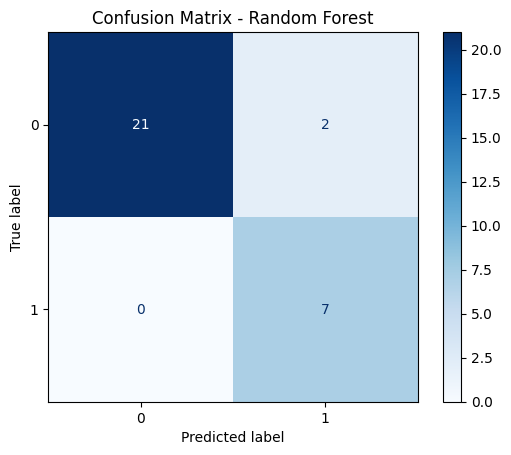

In [13]:
# 1. Buat confusion matrix dari label aktual dan prediksi
cm = confusion_matrix(y_test, predictions)

# 2. Buat display-nya dengan memberikan matrix dan label
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)

# 3. Plot
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

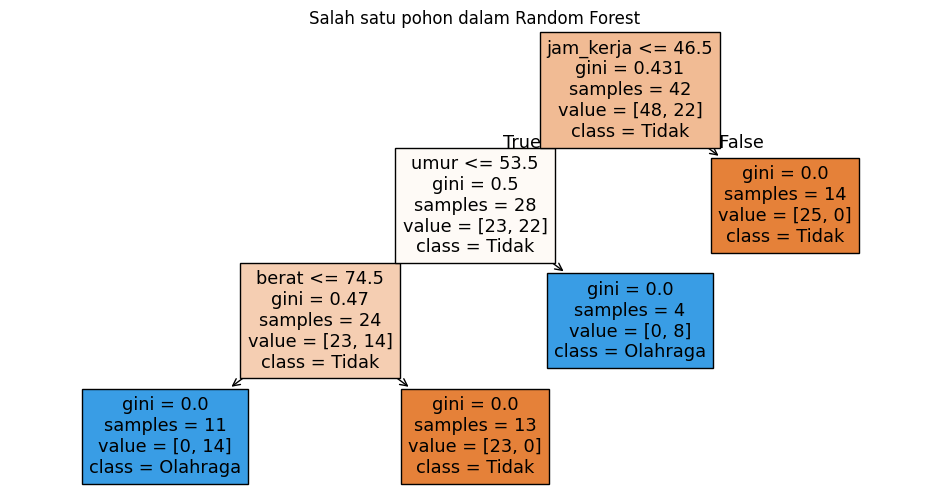

In [10]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 6))
plot_tree(rf.estimators_[0], feature_names=X.columns, class_names=["Tidak", "Olahraga"], filled=True)
plt.title("Salah satu pohon dalam Random Forest")
plt.show()